In [1]:
import flopy
import flopy.mf6 as mf6
import flopy.plot as fplt

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os

In [2]:
# load simulation
sim = flopy.mf6.MFSimulation.load(sim_ws='../input-files')
# load flow model
gwf = sim.get_model('peterson_flow')

loading simulation...
  loading simulation name file...
  loading tdis package...
  loading model gwf6...
    loading package dis...
    loading package ic...
    loading package npf...
    loading package riv...
    loading package obs...
    loading package wel...
    loading package chd...
    loading package sto...
    loading package rch...
    loading package oc...
  loading model gwt6...
    loading package dis...
    loading package ic...
    loading package adv...
    loading package dsp...
    loading package mst...
    loading package ist...
    loading package cnc...
    loading package ssm...
    loading package obs...
    loading package oc...
  loading model gwt6...
    loading package dis...
    loading package ic...
    loading package adv...
    loading package dsp...
    loading package mst...
    loading package ist...
    loading package cnc...
    loading package ssm...
    loading package obs...
    loading package oc...
  loading model gwt6...
    loading packag

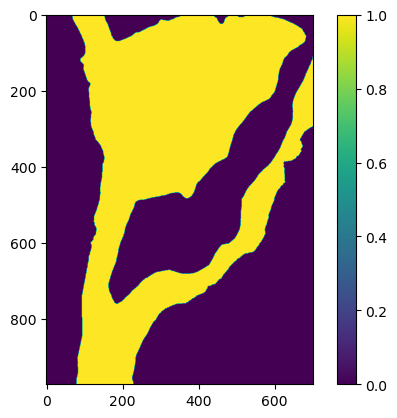

In [3]:
# get the IIDOMAIN array; in our case we only have one layer
ib = gwf.dis.idomain.array[0]
plt.imshow(ib)    
plt.colorbar()

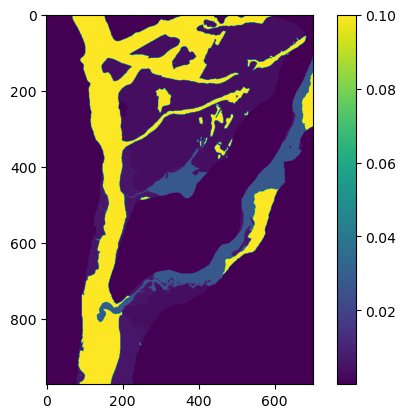

In [4]:
rchMult_matrix = np.loadtxt(os.path.join('..', 'input-files','data-files','rchMult.dat'))
#zones = np.where(np.isin(zones_matrix, [2, 3,4,5]), zones_matrix, 0)
rchMult= np.where(ib == 1, rchMult_matrix, 0)
rchMult = np.where(rchMult_matrix == 0, 0.0001, rchMult_matrix)
plt.imshow(rchMult)
plt.colorbar()

In [5]:
#np.savetxt('../input-files/data-files/rchMult.dat', rchMult, fmt='%.6f', delimiter=' ')

In [6]:
# # Load the data
# df = pd.read_excel("../input-files/data-files/tran-PFAS-targets.xlsx",sheet_name='PFOS')  # Change to your file path

# print(df.columns)

In [7]:
# # Convert Sdate to number of days since 1970-01-01
# df["time"] = (pd.to_datetime(df["SDate"]) - pd.Timestamp("1970-01-01")).dt.days

# # Pivot the table
# df_pivot = df.pivot(index="time", columns="Well_ID", values="Result_ngL").reset_index()

# # Save the transformed data
# df_pivot.to_excel("formatted_data.xlsx", index=0)  # Change filename as needed

# df_pivot # Print first few rows to verify
# df_pivot.to_csv('../input-files/data-files/tran-PFOS-observations.csv',index=False)

In [8]:
# # Load the data
# df = pd.read_excel("../input-files/data-files/tran-PFAS-targets.xlsx",sheet_name='PFOA')  # Change to your file path
# # Convert Sdate to number of days since 1970-01-01
# df["time"] = (pd.to_datetime(df["SDate"]) - pd.Timestamp("1970-01-01")).dt.days

# # Pivot the table
# df_pivot = df.pivot(index="time", columns="Well_ID", values="Result_ngL").reset_index()

# # Save the transformed data
# df_pivot.to_excel("formatted_data.xlsx", index=0)  # Change filename as needed

# df_pivot # Print first few rows to verify
# df_pivot.to_csv('../input-files/data-files/tran-PFOA-observations.csv',index=False)

In [9]:
# # Load the data
# df = pd.read_excel("../input-files/data-files/tran-PFAS-targets.xlsx",sheet_name='PFHxS')  # Change to your file path
# # Convert Sdate to number of days since 1970-01-01
# df["time"] = (pd.to_datetime(df["SDate"]) - pd.Timestamp("1970-01-01")).dt.days

# # Pivot the table
# df_pivot = df.pivot(index="time", columns="Well_ID", values="Result_ngL").reset_index()

# # Save the transformed data
# df_pivot.to_excel("formatted_data.xlsx", index=0)  # Change filename as needed

# df_pivot # Print first few rows to verify
# df_pivot.to_csv('../input-files/data-files/tran-PFHxS-observations.csv',index=False)

In [10]:
# import pandas as pd
# import re

# # Read the CSV
# df = pd.read_csv('../output-files/pfos_obs.csv', dtype=str)  # Read as string to avoid automatic misinterpretation

# # Function to fix scientific notation issues
# def fix_scientific_notation(value):
#     if isinstance(value, str):
#         return re.sub(r'(\d+)-(\d+)', r'\1e-\2', value)
#     return value  # Return unchanged if not a string

# # Apply the fix to all columns
# df = df.applymap(fix_scientific_notation)

# # Convert columns back to numeric where possible
# df = df.apply(pd.to_numeric, errors='ignore')

# # Save the fixed CSV
# df.to_csv('../output-files/pfos_obs_fixed.csv', index=False)

Unique values: [1. 2. 3. 4. 5.]


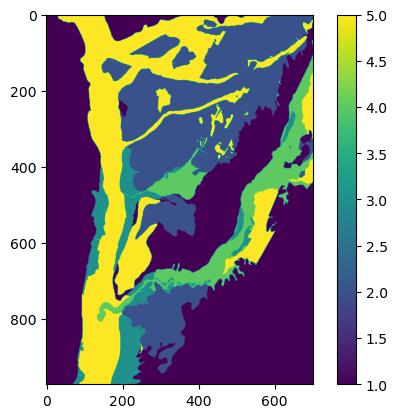

In [11]:
zones_matrix = np.loadtxt(os.path.join('..', 'peterson_template_tran','data-files','rchZones.dat'))
#zones = np.where(np.isin(zones_matrix, [2, 3,4,5]), zones_matrix, 0)
#zones= np.where(ib == 1, zones_matrix, 1)
zones=zones_matrix
unique_values = np.unique(zones)  # Get unique values
print("Unique values:", unique_values)
np.savetxt('../input-files/data-files/zones.dat', zones, fmt='%.6f', delimiter=' ')
plt.imshow(zones)
plt.colorbar()

In [12]:
por_matrix = np.loadtxt(os.path.join('..', 'peterson_template','data-files','tran-porosity.dat'))
# Read the .dat file
file_path = '../input-files/data-files/tran-porosity.dat'  # Change this to your actual file path
with open(file_path, "r") as file:
    data = file.readlines()

# Flatten and clean the data (assuming space-separated values)
values = [item for line in data for item in line.split()]
unique_values = np.unique(values)  # Get unique values

print("Unique values:", unique_values)

Unique values: ['0.055000' '0.169788' '0.274782' '0.499253' '0.500000']


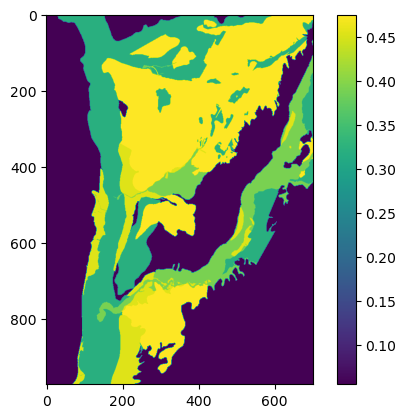

In [13]:
plt.imshow(por_matrix)
plt.colorbar()

In [14]:
matrix_1=zones.astype(float)
matrix_2= por_matrix.astype(float)

In [15]:
unique_values = np.unique(matrix_2)
results = {}

for val in unique_values:
    indices = np.argwhere(matrix_2 == val)  # Find indices of occurrences
    if indices.size > 0:  # Check if indices are found
        first_idx = tuple(indices[0])  
        corresponding_value = matrix_1[first_idx]  
        results[val] = corresponding_value
    else:
        print(f"Warning: Value {val} not found in matrix_2.")

# Print results
for key, value in results.items():
    print(f"Matrix2 Value: {key}, Matrix1 Value at First Occurrence: {value}")

Matrix2 Value: 0.055, Matrix1 Value at First Occurrence: 1.0
Matrix2 Value: 0.32, Matrix1 Value at First Occurrence: 5.0
Matrix2 Value: 0.39, Matrix1 Value at First Occurrence: 4.0
Matrix2 Value: 0.455, Matrix1 Value at First Occurrence: 3.0
Matrix2 Value: 0.475, Matrix1 Value at First Occurrence: 2.0


In [16]:
por_im_matrix = np.loadtxt(os.path.join('..', 'peterson_template','data-files','tran-immobile-porosity.dat'))
matrix_2= por_im_matrix.astype(float)

In [17]:
unique_values = np.unique(matrix_2)
results = {}

for val in unique_values:
    indices = np.argwhere(matrix_2 == val)  # Find indices of occurrences
    if indices.size > 0:  # Check if indices are found
        first_idx = tuple(indices[0])  
        corresponding_value = matrix_1[first_idx]  
        results[val] = corresponding_value
    else:
        print(f"Warning: Value {val} not found in matrix_2.")

# Print results
for key, value in results.items():
    print(f"Matrix2 Value: {key}, Matrix1 Value at First Occurrence: {value}")

Matrix2 Value: 0.016, Matrix1 Value at First Occurrence: 5.0
Matrix2 Value: 0.0468, Matrix1 Value at First Occurrence: 4.0
Matrix2 Value: 0.05445, Matrix1 Value at First Occurrence: 1.0
Matrix2 Value: 0.057, Matrix1 Value at First Occurrence: 2.0
Matrix2 Value: 0.45045, Matrix1 Value at First Occurrence: 3.0


In [18]:
bd = np.loadtxt(os.path.join('..', 'peterson_template','data-files','tran-bulk-density.dat'))
matrix_2= bd.astype(float)

In [19]:
unique_values = np.unique(matrix_2)
results = {}

for val in unique_values:
    indices = np.argwhere(matrix_2 == val)  # Find indices of occurrences
    if indices.size > 0:  # Check if indices are found
        first_idx = tuple(indices[0])  
        corresponding_value = matrix_1[first_idx]  
        results[val] = corresponding_value
    else:
        print(f"Warning: Value {val} not found in matrix_2.")

# Print results
for key, value in results.items():
    print(f"Matrix2 Value: {key}, Matrix1 Value at First Occurrence: {value}")

Matrix2 Value: 1762.5, Matrix1 Value at First Occurrence: 4.0
Matrix2 Value: 1818.0, Matrix1 Value at First Occurrence: 3.0
Matrix2 Value: 1842.5, Matrix1 Value at First Occurrence: 2.0
Matrix2 Value: 2250.5, Matrix1 Value at First Occurrence: 5.0
Matrix2 Value: 2500.0, Matrix1 Value at First Occurrence: 1.0


In [20]:
kd = np.loadtxt(os.path.join('..', 'peterson_template','data-files','tran-Kd-pfhxs.dat'))
matrix_2= kd.astype(float)

In [21]:
unique_values = np.unique(matrix_2)
results = {}

for val in unique_values:
    indices = np.argwhere(matrix_2 == val)  # Find indices of occurrences
    if indices.size > 0:  # Check if indices are found
        first_idx = tuple(indices[0])  
        corresponding_value = matrix_1[first_idx]  
        results[val] = corresponding_value
    else:
        print(f"Warning: Value {val} not found in matrix_2.")

# Print results
for key, value in results.items():
    print(f"Matrix2 Value: {key}, Matrix1 Value at First Occurrence: {value}")

Matrix2 Value: 6.0256e-07, Matrix1 Value at First Occurrence: 5.0
Matrix2 Value: 6.0256e-06, Matrix1 Value at First Occurrence: 2.0
Matrix2 Value: 0.00060256, Matrix1 Value at First Occurrence: 1.0


In [22]:
data = np.loadtxt('../peterson_template/data-files/flow-kfield.dat' )
# Check size and type
print("Shape of matrix:", data.shape)
print("Data type:", data.dtype)

Shape of matrix: (972, 700)
Data type: float64


In [23]:
# Read the .dat file
file_path = '../peterson_template/data-files/flow-kfield.dat'  # Change this to your actual file path
with open(file_path, "r") as file:
    data = file.readlines()

# Flatten and clean the data (assuming space-separated values)
values = [item for line in data for item in line.split()]
unique_values = np.unique(values)  # Get unique values

print("Unique values:", unique_values)

Unique values: ['0.010000000000000' '1.23412869600e+02' '23.03195400000000'
 '36.70163299999999' '43.63568700000000']


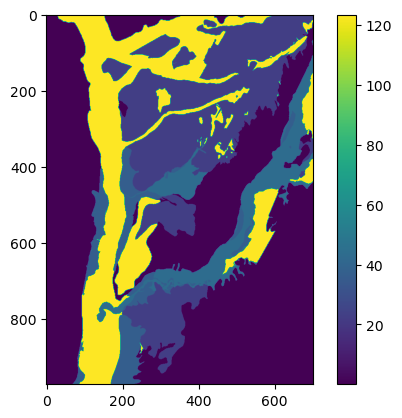

In [24]:
k_matrix = np.loadtxt(os.path.join('..', 'peterson_template','data-files','flow-kfield.dat'))
hk= np.where(ib == 1, k_matrix, 0)
hk = np.where(k_matrix == 0, 0.0001, k_matrix)
plt.imshow(hk)
plt.colorbar()

In [25]:
data = np.loadtxt('../input-files/data-files/flow-kfield.dat' )
# Check size and type
print("Shape of matrix:", data.shape)
print("Data type:", data.dtype)

Shape of matrix: (972, 700)
Data type: float64


In [26]:
# Read the .dat file
file_path = '../input-files/data-files/flow-kfield.dat'  # Change this to your actual file path
with open(file_path, "r") as file:
    data = file.readlines()

# Flatten and clean the data (assuming space-separated values)
values = [item for line in data for item in line.split()]
unique_values = np.unique(values)  # Get unique values

print("Unique values:", unique_values)

Unique values: ['0.100000' '122.191000' '23.032000' '36.701600' '43.635700']


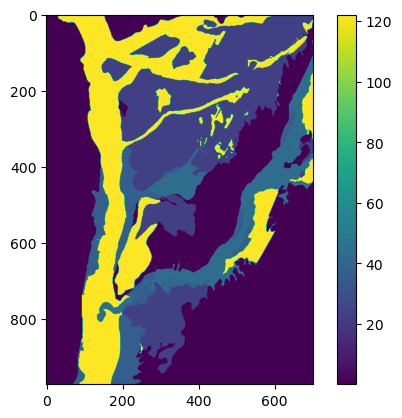

In [27]:
k_matrix = np.loadtxt(os.path.join('..', 'input-files','data-files','flow-kfield.dat'))
hk= np.where(ib == 1, k_matrix, 0)
hk = np.where(k_matrix == 0, 0.0001, k_matrix)
plt.imshow(hk)
plt.colorbar()

In [28]:
# Get unique values sorted in ascending order
unique_vals = np.sort(np.unique(hk))

# Create a mapping from original values to ranks (1 to 5)
rank_map = {val: rank for rank, val in enumerate(unique_vals, start=1)}

# Vectorized replacement using np.vectorize
ranked_arr = np.vectorize(rank_map.get)(hk)

np.savetxt('../input-files/data-files/zones.dat', ranked_arr, fmt='%.6f', delimiter=' ')

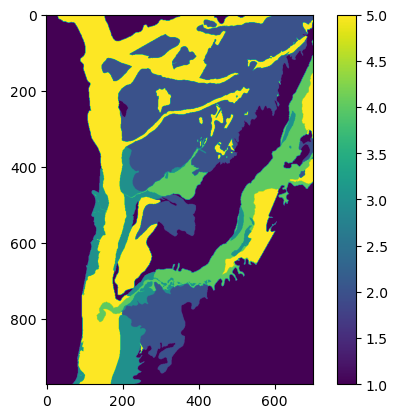

In [29]:
plt.imshow(ranked_arr)
plt.colorbar()

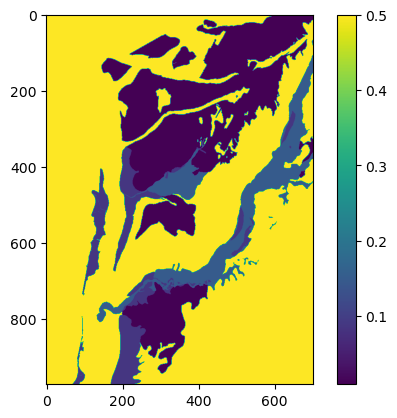

In [30]:
array = ranked_arr

# Mapping dictionary
mapping = {1: 0.5 , 2: 0.00954316, 3: 0.0862207, 4: 0.149592, 5: 0.49981}

# Replace values using vectorized approach
new_array = np.vectorize(mapping.get)(array)

plt.imshow(new_array)
plt.colorbar()

In [31]:
np.savetxt('../input-files/data-files/flow-recharge-mult.dat', new_array, fmt='%.6f', delimiter=' ')

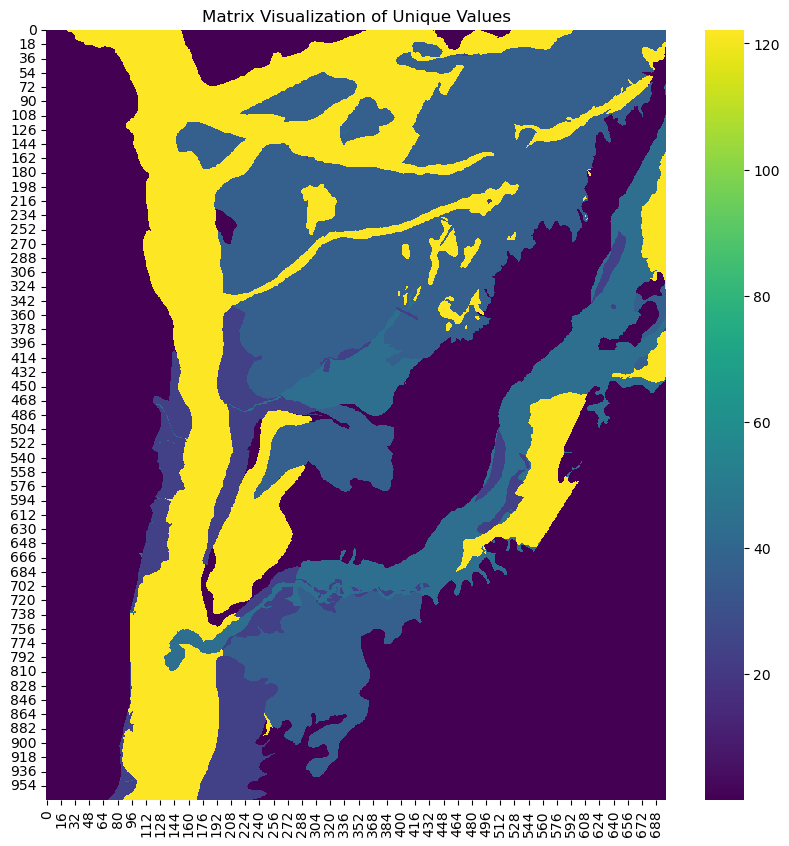

In [33]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load data from file (assuming it's a space-separated text file)
data = np.loadtxt("../input-files/data-files/flow-kfield.dat")  # Update with actual filename

# Plot the heatmap
plt.figure(figsize=(10, 10))  # Adjust size as needed
sns.heatmap(data, cmap="viridis", square=False, cbar=True)

plt.title("Matrix Visualization of Unique Values")
plt.show()

In [4]:
# Read the .dat file
file_path = '../input-files/data-files/rchMult.dat'  # Change this to your actual file path
with open(file_path, "r") as file:
    data = file.readlines()

# Flatten and clean the data (assuming space-separated values)
values = [item for line in data for item in line.split()]
unique_values = np.unique(values)  # Get unique values

print("Unique values:", unique_values)

Unique values: ['1.000000000000000056e-01' '2.750000000000000014e-02'
 '3.749999999999999861e-03' '6.250000000000000300e-06'
 '6.250000000000000347e-03']


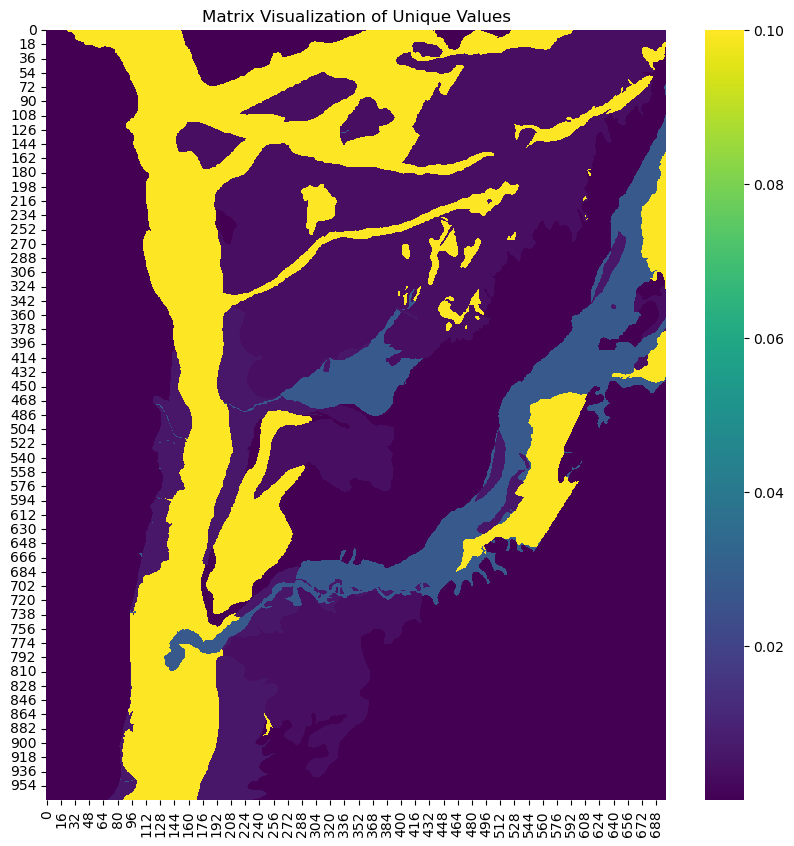

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load data from file (assuming it's a space-separated text file)
data = np.loadtxt("../input-files/data-files/rchMult.dat")  # Update with actual filename

# Plot the heatmap
plt.figure(figsize=(10, 10))  # Adjust size as needed
sns.heatmap(data, cmap="viridis", square=False, cbar=True)

plt.title("Matrix Visualization of Unique Values")
plt.show()


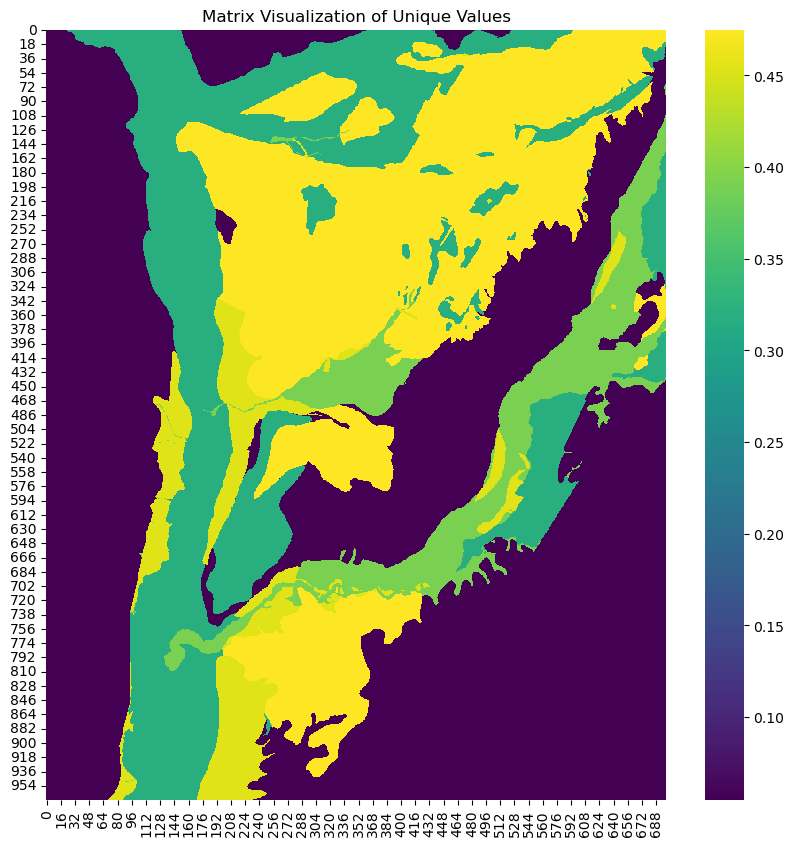

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load data from file (assuming it's a space-separated text file)
data = np.loadtxt("../input-files/data-files/tran-porosity.dat")  # Update with actual filename

# Plot the heatmap
plt.figure(figsize=(10, 10))  # Adjust size as needed
sns.heatmap(data, cmap="viridis", square=False, cbar=True)

plt.title("Matrix Visualization of Unique Values")
plt.show()


In [3]:
# Read the .dat file
file_path = '../input-files/data-files/tran-immobile-porosity.dat'  # Change this to your actual file path
with open(file_path, "r") as file:
    data = file.readlines()

# Flatten and clean the data (assuming space-separated values)
values = [item for line in data for item in line.split()]
unique_values = np.unique(values)  # Get unique values

print("Unique values:", unique_values)

Unique values: ['1.60000000e-02' '4.50450000e-01' '4.68000000e-02' '5.44500000e-02'
 '5.70000000e-02']


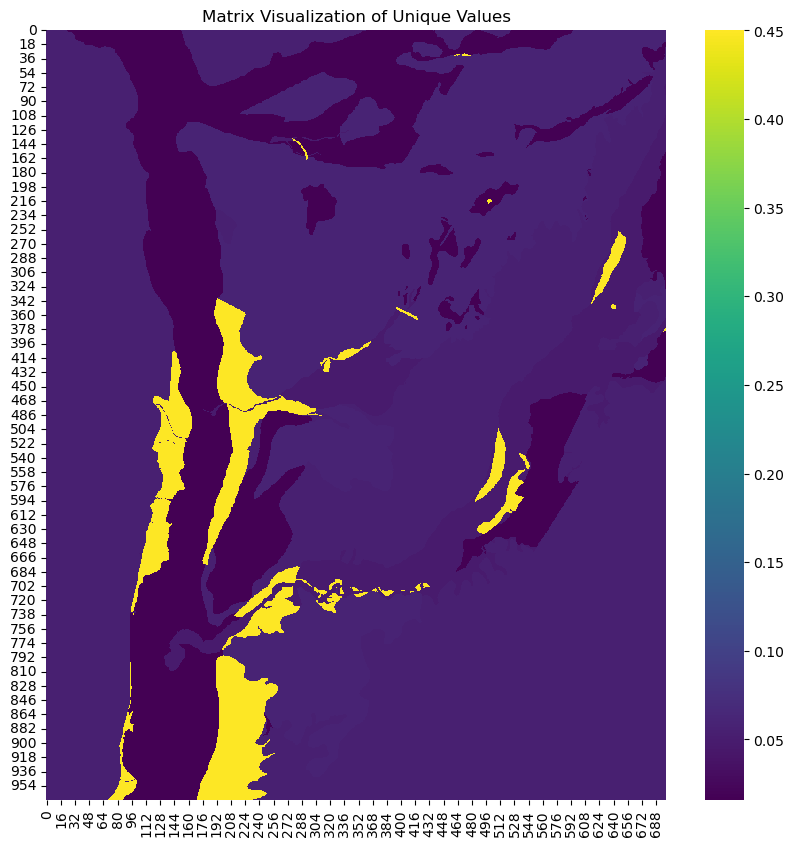

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load data from file (assuming it's a space-separated text file)
data = np.loadtxt("../input-files/data-files/tran-immobile-porosity.dat")  # Update with actual filename

# Plot the heatmap
plt.figure(figsize=(10, 10))  # Adjust size as needed
sns.heatmap(data, cmap="viridis", square=False, cbar=True)

plt.title("Matrix Visualization of Unique Values")
plt.show()


In [4]:
# Read the .dat file
file_path = '../input-files/data-files/tran-Kd-pfos.dat'  # Change this to your actual file path
with open(file_path, "r") as file:
    data = file.readlines()

# Flatten and clean the data (assuming space-separated values)
values = [item for line in data for item in line.split()]
unique_values = np.unique(values)  # Get unique values

print("Unique values:", unique_values)

Unique values: ['2.75400000e-03' '2.75400000e-05' '2.75400000e-06']


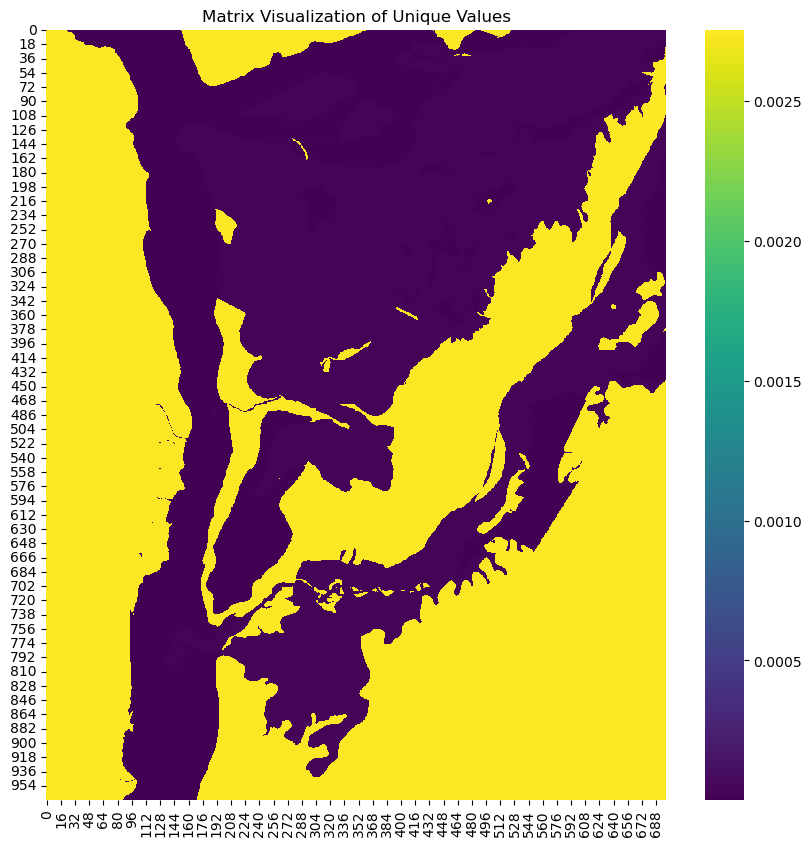

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load data from file (assuming it's a space-separated text file)
data = np.loadtxt("../input-files/data-files/tran-Kd-pfos.dat")  # Update with actual filename

# Plot the heatmap
plt.figure(figsize=(10, 10))  # Adjust size as needed
sns.heatmap(data, cmap="viridis", square=False, cbar=True)

plt.title("Matrix Visualization of Unique Values")
plt.show()


In [5]:
# Read the .dat file
file_path = '../input-files/data-files/tran-Kd-pfoa.dat'  # Change this to your actual file path
with open(file_path, "r") as file:
    data = file.readlines()

# Flatten and clean the data (assuming space-separated values)
values = [item for line in data for item in line.split()]
unique_values = np.unique(values)  # Get unique values

print("Unique values:", unique_values)

Unique values: ['1.14800000e-03' '1.14800000e-05' '1.14800000e-06']


In [6]:
# Read the .dat file
file_path = '../input-files/data-files/tran-Kd-pfhxs.dat'  # Change this to your actual file path
with open(file_path, "r") as file:
    data = file.readlines()

# Flatten and clean the data (assuming space-separated values)
values = [item for line in data for item in line.split()]
unique_values = np.unique(values)  # Get unique values

print("Unique values:", unique_values)

Unique values: ['6.02560000e-04' '6.02560000e-06' '6.02560000e-07']


In [11]:
# Read the .dat file
file_path = '../input-files/data-files/flow-spec-yield.dat'  # Change this to your actual file path
with open(file_path, "r") as file:
    data = file.readlines()

# Flatten and clean the data (assuming space-separated values)
values = [item for line in data for item in line.split()]
unique_values = np.unique(values)  # Get unique values

print("Unique values:", unique_values)

Unique values: ['1.00000000e-02' '1.90000000e-01' '2.60000000e-01' '3.20000000e-01'
 '5.00000000e-02']


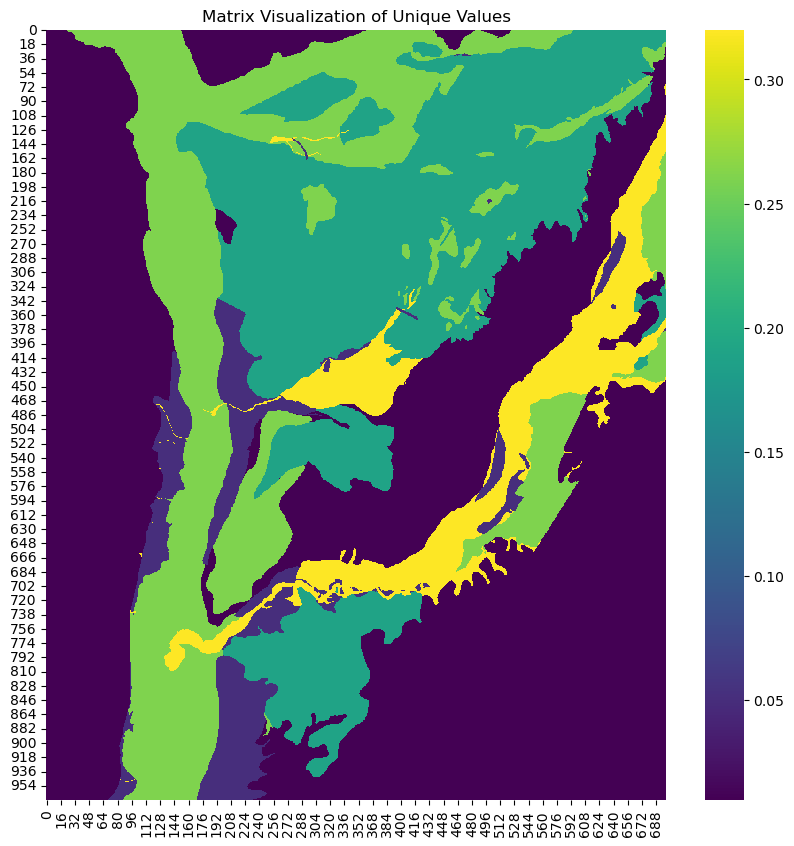

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load data from file (assuming it's a space-separated text file)
data = np.loadtxt("../input-files/data-files/flow-spec-yield.dat")  # Update with actual filename

# Plot the heatmap
plt.figure(figsize=(10, 10))  # Adjust size as needed
sns.heatmap(data, cmap="viridis", square=False, cbar=True)

plt.title("Matrix Visualization of Unique Values")
plt.show()

In [12]:
# Read the .dat file
file_path = '../input-files/data-files/flow-spec-storage.dat'  # Change this to your actual file path
with open(file_path, "r") as file:
    data = file.readlines()

# Flatten and clean the data (assuming space-separated values)
values = [item for line in data for item in line.split()]
unique_values = np.unique(values)  # Get unique values

print("Unique values:", unique_values)

Unique values: ['1.07910000e-06' '4.20680660e-06' '4.60866344e-06' '5.24054124e-06'
 '5.99008410e-06']


In [13]:
# Read the .dat file
file_path = '../input-files/data-files/tran-bulk-density.dat'  # Change this to your actual file path
with open(file_path, "r") as file:
    data = file.readlines()

# Flatten and clean the data (assuming space-separated values)
values = [item for line in data for item in line.split()]
unique_values = np.unique(values)  # Get unique values

print("Unique values:", unique_values)

Unique values: ['1.76250000e+03' '1.81800000e+03' '1.84250000e+03' '2.25050000e+03'
 '2.50000000e+03']
